这个notebook用来分析和绘制rabi振荡的结果

In [2]:
from datetime import datetime
import os

exp_date = datetime.today().strftime("%Y-%m-%d")
print(exp_date)

results_path = r"D:\yangyuanming\artiq_control\302adc_dds2_ttl2\experiment\results"
file_path = os.path.join(results_path, exp_date)
print(file_path)

dirs = [name for name in os.listdir(file_path) if os.path.isdir(os.path.join(file_path, name))]
print(dirs)

new_dir = os.path.join(file_path, dirs[-1])
print(new_dir)

exp_results = [name for name in os.listdir(new_dir) if os.path.exists(os.path.join(new_dir, name))]
print(exp_results)

new_exp_result = os.path.join(new_dir, exp_results[-1])
print(new_exp_result)

2025-09-23
D:\yangyuanming\artiq_control\302adc_dds2_ttl2\experiment\results\2025-09-23
['13', '14', '15']
D:\yangyuanming\artiq_control\302adc_dds2_ttl2\experiment\results\2025-09-23\15
['000000794-DDS_Single_Channel_Test.h5', '000000795-DDS_Single_Channel_Test.h5', '000000796-DDS_Single_Channel_Test.h5', '000000797-DDS_Single_Channel_Test.h5', '000000798-DDS_Single_Channel_Test.h5', '000000799-DDS_Single_Channel_Test.h5', '000000800-DDS_Single_Channel_Test.h5', '000000801-DDS_Single_Channel_Test.h5', '000000802-DDS_Single_Channel_Test.h5', '000000803-DDS_Single_Channel_Test.h5', '000000804-DDS_Single_Channel_Test.h5', '000000805-DDS_Single_Channel_Test.h5', '000000806-DDS_Single_Channel_Test.h5', '000000807-DDS_Single_Channel_Test.h5', '000000808-DDS_Single_Channel_Test.h5', '000000809-DDS_Single_Channel_Test.h5', '000000810-DDS_Single_Channel_Test.h5', '000000811-DDS_Single_Channel_Test.h5', '000000812-DDS_Single_Channel_Test.h5', '000000813-DDS_Single_Channel_Test.h5', '000000814-D

In [15]:
# 读取实验数据
import h5py
import numpy as np

resultfile = new_exp_result
data = None
axis_data = None

with h5py.File(resultfile, "r") as f:
    if "datasets" in f:
        ds_names = list(f["datasets"].keys())
        
        # 查找channel_counts数据
        for ds_name in ds_names:
            if "channel_counts" in ds_name:
                data = f[f"datasets/{ds_name}"][()]
                break
        
        # 查找axis_0数据
        for ds_name in ds_names:
            if "axis_0" in ds_name:
                axis_data = f[f"datasets/{ds_name}"][()]
                break

print(f"数据读取完成: {data.shape if data is not None else 'None'}")


        


文件顶层 keys: ['archive', 'artiq_version', 'datasets', 'expid', 'rid', 'run_time', 'start_time']
archive: <class 'h5py._hl.group.Group'>, shape: N/A
artiq_version: <class 'h5py._hl.dataset.Dataset'>, shape: ()
datasets: <class 'h5py._hl.group.Group'>, shape: N/A
expid: <class 'h5py._hl.dataset.Dataset'>, shape: ()
rid: <class 'h5py._hl.dataset.Dataset'>, shape: ()
run_time: <class 'h5py._hl.dataset.Dataset'>, shape: ()
start_time: <class 'h5py._hl.dataset.Dataset'>, shape: ()
datasets下的数据集: ['ndscan.rid_856.analysis_results', 'ndscan.rid_856.annotations', 'ndscan.rid_856.axes', 'ndscan.rid_856.channels', 'ndscan.rid_856.completed', 'ndscan.rid_856.fragment_fqn', 'ndscan.rid_856.ndscan_schema_revision', 'ndscan.rid_856.online_analyses', 'ndscan.rid_856.points.axis_0', 'ndscan.rid_856.points.channel_counts', 'ndscan.rid_856.seed', 'ndscan.rid_856.source_id']
成功读取channel_counts数据，路径: datasets/ndscan.rid_856.points.channel_counts
数据形状: (1100, 4)
数据类型: float64
成功读取axis_0数据，路径: datasets/ndscan.

In [16]:
# 绘制时间-计数图
import matplotlib.pyplot as plt

if data is not None:
    pmt_channel = 3 if data.shape[1] > 3 else 0
    pmt_data = data[:, pmt_channel]
    
    # 时间轴
    if axis_data is not None:
        x = axis_data * 1e6  # 微秒
        xlabel = '时间 (μs)'
    else:
        x = np.arange(len(pmt_data))
        xlabel = '测量点'
    
    y = pmt_data
    
    # 绘制点图
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'ro-', markersize=6, linewidth=1, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel('计数')
    plt.title('计数 vs 时间')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 简单统计
    print(f"数据点: {len(y)}")
    print(f"计数范围: {np.min(y)} - {np.max(y)}")
    print(f"平均计数: {np.mean(y):.1f}")
    
else:
    print("无数据")



数据分析:
数据形状: (1100, 4)
通道 0: 平均值=0.00, 标准差=0.00, 范围=[0.00, 0.00]
通道 1: 平均值=0.00, 标准差=0.00, 范围=[0.00, 0.00]
通道 2: 平均值=0.00, 标准差=0.00, 范围=[0.00, 0.00]
通道 3: 平均值=7.27, 标准差=2.79, 范围=[0.00, 21.00]

轴数据:
轴数据形状: (1100,)
轴数据范围: [0.000000, 0.000100]
轴数据步长: 0.000000


C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\971681077.py:44: UserWarning: Glyph 39564 (\N{CJK 

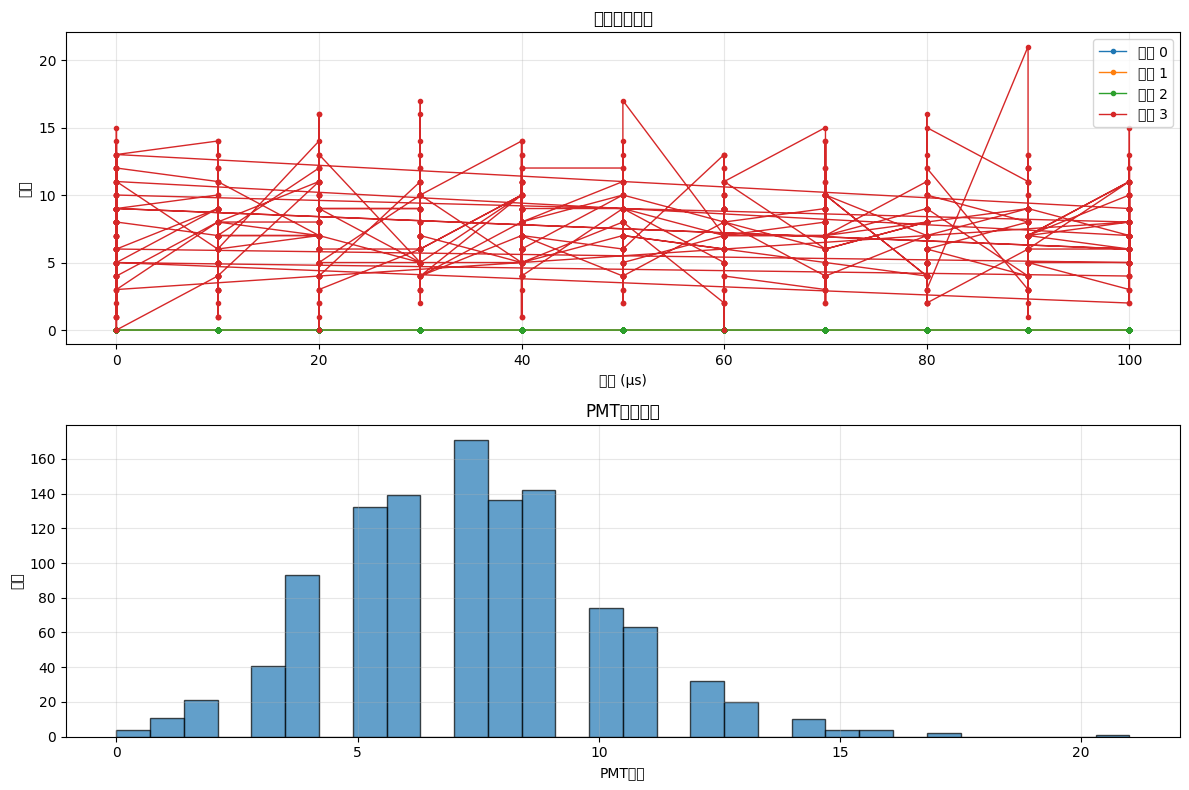

H5文件完整结构:
文件结构:
📁 组: archive
📊 数据集: artiq_version
   形状: ()
   类型: object
   内容: b'8.9006+17be223'

📁 组: datasets
  📊 数据集: datasets/ndscan.rid_856.analysis_results
     形状: ()
     类型: object
     内容: b'{}'

  📊 数据集: datasets/ndscan.rid_856.annotations
     形状: ()
     类型: object
     内容: b'[]'

  📊 数据集: datasets/ndscan.rid_856.axes
     形状: ()
     类型: object
     内容: b'[{"param": {"fqn": "scan_exp2.BaseSequence.mw_duration", "description": "MW duration", "type": "float", "default": "9.999999999999999e-05", "spec": {"is_scannable": true, "scale": 1e-06, "step": 1e-07, "unit": "us"}}, "path": "", "min": 0.0, "max": 9.999999999999999e-05, "increment": 9.999999999999999e-06}]'

  📊 数据集: datasets/ndscan.rid_856.channels
     形状: ()
     类型: object
     内容: b'{"counts": {"path": "counts", "description": "", "type": "opaque"}}'

  📊 数据集: datasets/ndscan.rid_856.completed
     形状: ()
     类型: bool
     内容: True

  📊 数据集: datasets/ndscan.rid_856.fragment_fqn
     形状: ()
     类型: object
     内

数据快速概览:
✅ 成功读取实验数据
📊 数据维度: 1100 个测量点 × 4 个通道
📈 各通道数据范围:
   通道 0: 0.0 ~ 0.0 (均值: 0.0)
   通道 1: 0.0 ~ 0.0 (均值: 0.0)
   通道 2: 0.0 ~ 0.0 (均值: 0.0)
   通道 3: 0.0 ~ 21.0 (均值: 7.3)
⚙️  扫描参数: 0.000000 ~ 0.000100
📏 扫描步数: 1100
🔢 平均步长: 0.000000

🔍 数据质量检查:
   是否有NaN值: 否
   是否有无穷大值: 否
   数据是否全为零: 否


C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 25195 (\N{CJK UNIFIED IDEOGRAPH-626B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 25551 (\N{CJK UNIFIED IDEOGRAPH-63CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1813985610.py:58: UserWarning: Glyph 38543 (\

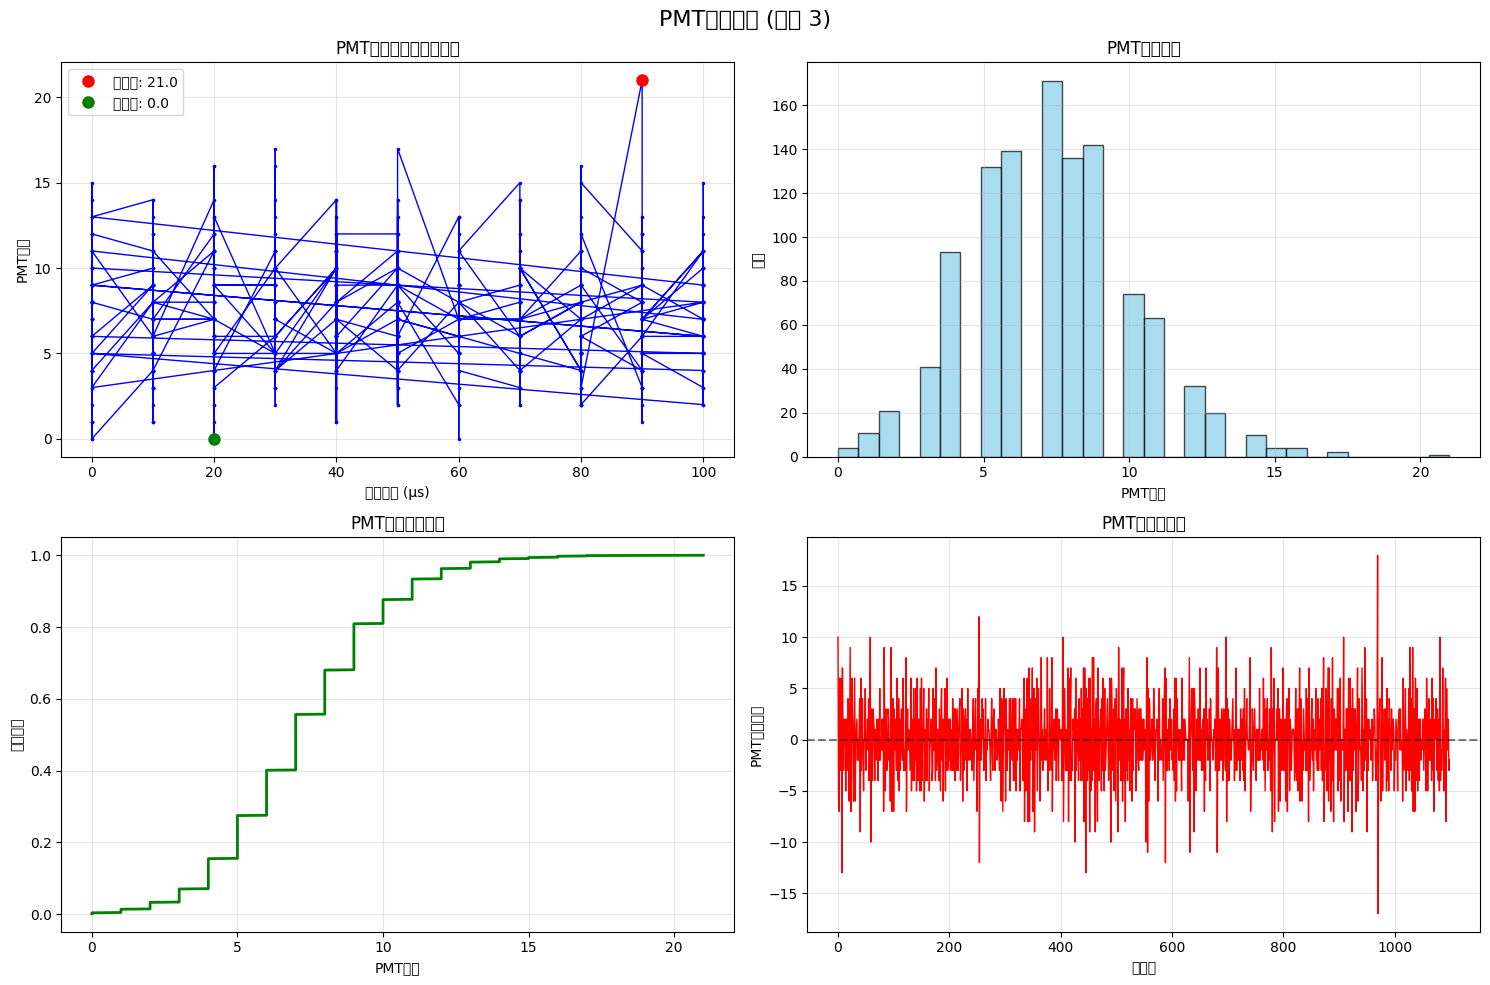


🎯 PMT数据关键信息:
   数据点总数: 1100
   计数范围: 0.0 ~ 21.0
   平均计数: 7.27
   计数标准差: 2.79
   计数中位数: 7.00


C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\TIQC\AppData\Local\Temp\ipykernel_132252\1074451390.py:54: UserWarning: Glyph 38543 (\

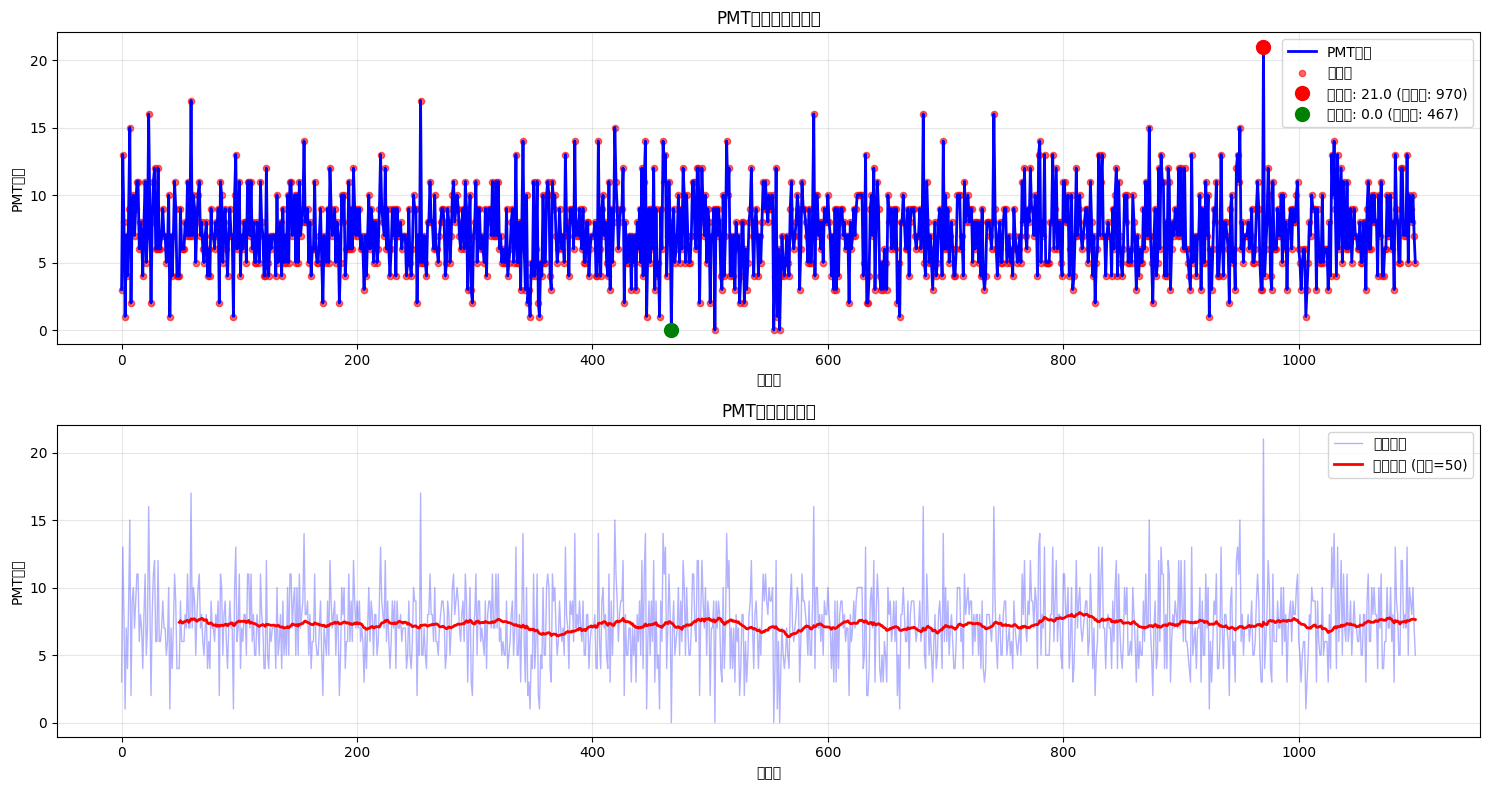


⏰ PMT时间序列信息:
   总测量时间点: 1100
   时间范围: 0 ~ 1099
   最大值出现在时间点: 970
   最小值出现在时间点: 467
   最大值: 21.0
   最小值: 0.0

📈 PMT变化趋势:
   最大单步增加: 18.0 (时间点: 969)
   最大单步减少: -17.0 (时间点: 970)
   平均变化率: 0.0018
   变化率标准差: 3.9822


In [21]:
# PMT随时间变化的图
import matplotlib.pyplot as plt
import numpy as np

if 'data' in locals() and data is not None:
    pmt_channel = 3 if data.shape[1] > 3 else 0
    pmt_data = data[:, pmt_channel]
    
    # 创建时间轴（假设每个测量点代表一个时间步）
    time_points = np.arange(len(pmt_data))
    
    # 绘制PMT随时间变化的图
    plt.figure(figsize=(15, 8))
    
    # 主图：PMT计数随时间变化
    plt.subplot(2, 1, 1)
    plt.plot(time_points, pmt_data, 'b-', linewidth=2, label='PMT计数')
    plt.scatter(time_points, pmt_data, c='red', s=20, alpha=0.6, label='数据点')
    
    # 标记最大值和最小值
    max_idx = np.argmax(pmt_data)
    min_idx = np.argmin(pmt_data)
    plt.plot(max_idx, pmt_data[max_idx], 'ro', markersize=10, label=f'最大值: {pmt_data[max_idx]} (时间点: {max_idx})')
    plt.plot(min_idx, pmt_data[min_idx], 'go', markersize=10, label=f'最小值: {pmt_data[min_idx]} (时间点: {min_idx})')
    
    plt.xlabel('时间点')
    plt.ylabel('PMT计数')
    plt.title('PMT计数随时间变化')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 子图：PMT计数的移动平均（平滑曲线）
    plt.subplot(2, 1, 2)
    window_size = min(50, len(pmt_data) // 10)  # 移动平均窗口大小
    if window_size > 1:
        # 计算移动平均
        moving_avg = np.convolve(pmt_data, np.ones(window_size)/window_size, mode='valid')
        time_avg = np.arange(window_size-1, len(pmt_data))
        
        plt.plot(time_points, pmt_data, 'b-', alpha=0.3, linewidth=1, label='原始数据')
        plt.plot(time_avg, moving_avg, 'r-', linewidth=2, label=f'移动平均 (窗口={window_size})')
        plt.xlabel('时间点')
        plt.ylabel('PMT计数')
        plt.title('PMT计数移动平均')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.plot(time_points, pmt_data, 'b-', linewidth=2)
        plt.xlabel('时间点')
        plt.ylabel('PMT计数')
        plt.title('PMT计数随时间变化')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印时间相关信息
    print(f"\n⏰ PMT时间序列信息:")
    print(f"   总测量时间点: {len(pmt_data)}")
    print(f"   时间范围: 0 ~ {len(pmt_data)-1}")
    print(f"   最大值出现在时间点: {max_idx}")
    print(f"   最小值出现在时间点: {min_idx}")
    print(f"   最大值: {pmt_data[max_idx]}")
    print(f"   最小值: {pmt_data[min_idx]}")
    
    # 计算PMT的变化趋势
    pmt_diff = np.diff(pmt_data)
    print(f"\n📈 PMT变化趋势:")
    print(f"   最大单步增加: {np.max(pmt_diff)} (时间点: {np.argmax(pmt_diff)})")
    print(f"   最大单步减少: {np.min(pmt_diff)} (时间点: {np.argmin(pmt_diff)})")
    print(f"   平均变化率: {np.mean(pmt_diff):.4f}")
    print(f"   变化率标准差: {np.std(pmt_diff):.4f}")
    
else:
    print("❌ 没有数据可以绘制PMT随时间变化")


In [ ]:
# 绘制横轴为时间、纵轴为计数的点图
import matplotlib.pyplot as plt
import numpy as np

if 'data' in locals() and data is not None:
    pmt_channel = 3 if data.shape[1] > 3 else 0
    pmt_data = data[:, pmt_channel]
    
    # 如果有轴数据，使用轴数据作为时间；否则使用数据点索引
    if 'axis_data' in locals() and axis_data is not None:
        time_data = axis_data * 1e6  # 转换为微秒
        xlabel = '微波持续时间 (μs)'
    else:
        time_data = np.arange(len(pmt_data))
        xlabel = '测量点'
    
    # 创建图形
    plt.figure(figsize=(12, 8))
    
    # 绘制散点图
    plt.scatter(time_data, pmt_data, c='red', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # 也可以添加连线（可选）
    plt.plot(time_data, pmt_data, 'b-', alpha=0.3, linewidth=1, label='连线')
    
    # 标记最大值和最小值
    max_idx = np.argmax(pmt_data)
    min_idx = np.argmin(pmt_data)
    plt.scatter(time_data[max_idx], pmt_data[max_idx], c='green', s=100, marker='^', 
                edgecolors='black', linewidth=2, label=f'最大值: {pmt_data[max_idx]}')
    plt.scatter(time_data[min_idx], pmt_data[min_idx], c='blue', s=100, marker='v', 
                edgecolors='black', linewidth=2, label=f'最小值: {pmt_data[min_idx]}')
    
    # 设置标签和标题
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('光学计数', fontsize=12)
    plt.title('光学计数随微波持续时间变化', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 设置坐标轴范围
    plt.xlim(np.min(time_data) - 0.05*(np.max(time_data) - np.min(time_data)), 
             np.max(time_data) + 0.05*(np.max(time_data) - np.min(time_data)))
    
    plt.tight_layout()
    plt.show()
    
    # 打印数据信息
    print(f"\n📊 实验数据信息:")
    print(f"   数据点总数: {len(pmt_data)}")
    if 'axis_data' in locals() and axis_data is not None:
        print(f"   时间范围: {np.min(time_data):.2f} ~ {np.max(time_data):.2f} μs")
        print(f"   时间步长: {np.mean(np.diff(time_data)):.2f} μs")
    print(f"   计数范围: {np.min(pmt_data)} ~ {np.max(pmt_data)}")
    print(f"   平均计数: {np.mean(pmt_data):.2f}")
    print(f"   计数标准差: {np.std(pmt_data):.2f}")
    
    # 找到最佳工作点（最高计数）
    best_idx = np.argmax(pmt_data)
    print(f"\n🎯 最佳工作点:")
    print(f"   最佳时间: {time_data[best_idx]:.2f} μs")
    print(f"   最佳计数: {pmt_data[best_idx]}")
    
else:
    print("❌ 没有数据可以绘制")


In [ ]:
# 简洁版本：时间-计数点图
if 'data' in locals() and data is not None:
    pmt_channel = 3 if data.shape[1] > 3 else 0
    pmt_data = data[:, pmt_channel]
    
    # 时间轴
    if 'axis_data' in locals() and axis_data is not None:
        x = axis_data * 1e6  # 微秒
        xlabel = '时间 (μs)'
    else:
        x = np.arange(len(pmt_data))
        xlabel = '测量点'
    
    y = pmt_data
    
    # 绘制点图
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'ro-', markersize=6, linewidth=1, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel('计数')
    plt.title('计数 vs 时间')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 简单统计
    print(f"数据点: {len(y)}")
    print(f"计数范围: {np.min(y)} - {np.max(y)}")
    print(f"平均计数: {np.mean(y):.1f}")
    
else:
    print("无数据")
